# Object Detection Webcam using OpenVINO Toolkit

This notebook demonstrates **real-time object detection** using the **OpenVINO** toolkit and OpenCV's webcam interface. The workflow covers:

1. **Model Acquisition** — downloading a pre-trained object detection model (`person-vehicle-bike-detection-crossroad-yolov3-1020`) from the OpenVINO Model Zoo (OMZ) and converting it to OpenVINO IR format (`.xml` + `.bin`).
2. **OpenVINO Inference** — loading the IR model with `openvino.Core`, compiling it for the CPU, and running inference using the OpenVINO Python API.
3. **Pre- and Post-Processing** — resizing/normalizing input frames and decoding YOLOv3 multi-scale outputs with NMS.
4. **Webcam Demo** — capturing frames from the webcam, running detection, and drawing bounding boxes with class labels and confidence scores.

> **Note:** The model is pre-trained on COCO and detects 80 object categories including **persons**, **vehicles** (cars, buses, trucks), and **bikes** (bicycles, motorcycles).

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from openvino.runtime import Core
import time, os

## 1. Model Setup — OpenVINO IR Model

We use the **OpenVINO Model Zoo (OMZ)** to obtain a pre-trained object detection model. The `omz_downloader` tool downloads the model and converts it to OpenVINO IR format (`.xml` + `.bin`). The model is then loaded with `openvino.Core` and compiled for CPU inference.

If the model is already present in the working directory, it will be used directly. Otherwise, the notebook attempts to download it using the OMZ downloader.

In [2]:
MODEL_NAME = 'person-vehicle-bike-detection-crossroad-yolov3-1020'
MODEL_DIR = os.path.join(os.getcwd(), MODEL_NAME)
FP = 'FP16'

xml_path = os.path.join(MODEL_DIR, FP, f'{MODEL_NAME}.xml')
bin_path = os.path.join(MODEL_DIR, FP, f'{MODEL_NAME}.bin')

if not os.path.exists(xml_path):
    print(f'Model not found at {xml_path}')
    print('Downloading from OpenVINO Model Zoo...')
    import subprocess
    result = subprocess.run(
        ['omz_downloader', '--name', MODEL_NAME, '--output_dir', os.getcwd()],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print('Download failed. Please run the following command manually:')
        print(f'  omz_downloader --name {MODEL_NAME} --output_dir {os.getcwd()}')
        raise RuntimeError('Model download failed')
    print('Model downloaded successfully.')
else:
    print(f'Using existing model: {xml_path}')

core = Core()
model = core.read_model(xml_path)
compiled_model = core.compile_model(model, 'CPU')
infer_request = compiled_model.create_infer_request()

input_layer = compiled_model.input(0)
output_layers = [compiled_model.output(i) for i in range(len(compiled_model.outputs))]

print(f'Input shape: {input_layer.shape}, dtype: {input_layer.element_type}')
print(f'Number of output layers: {len(output_layers)}')
for i, out in enumerate(output_layers):
    print(f'  Output {i}: shape={out.shape}, dtype={out.element_type}')

Model not found at /workspaces/Computer-Vision-/CV_Assignment_10/person-vehicle-bike-detection-crossroad-yolov3-1020/FP16/person-vehicle-bike-detection-crossroad-yolov3-1020.xml
Model downloaded successfully.


RuntimeError: Exception from src/inference/src/cpp/core.cpp:90:
Check 'util::directory_exists(path) || util::file_exists(path)' failed at src/frontends/common/src/frontend.cpp:113:
FrontEnd API failed with GeneralFailure:
ir: Could not open the file: "/workspaces/Computer-Vision-/CV_Assignment_10/person-vehicle-bike-detection-crossroad-yolov3-1020/FP16/person-vehicle-bike-detection-crossroad-yolov3-1020.xml"



## 2. Class Labels and Preprocessing

The model detects **80 COCO object categories** including persons, vehicles, and bikes. We define the class labels and a preprocessing function that resizes the input frame to the model's expected size (`416x416`), normalizes pixel values to `[0, 1]`, and keeps the **BGR** channel order expected by the OpenVINO IR model.

In [3]:
COCO_CLASSES = [
    'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light',
    'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee',
    'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard',
    'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple',
    'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch',
    'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard',
    'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase',
    'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

INPUT_SIZE = 416

def preprocess(frame_bgr):
    """Resize and normalize a BGR frame for model input (NHWC)."""
    h, w = frame_bgr.shape[:2]
    scale = min(INPUT_SIZE / h, INPUT_SIZE / w)
    new_h, new_w = int(h * scale), int(w * scale)
    resized = cv2.resize(frame_bgr, (new_w, new_h))
    padded = np.full((INPUT_SIZE, INPUT_SIZE, 3), 114, dtype=np.uint8)
    padded[:new_h, :new_w] = resized
    blob = padded.astype(np.float32) / 255.0
    blob = np.expand_dims(blob, axis=0)
    return blob, scale

## 3. YOLOv3 Post-Processing — Decode Outputs and Apply NMS

The YOLOv3 model produces **three output tensors** at different scales (13×13, 26×26, 52×52). Each tensor encodes bounding box predictions for anchors at that scale. We decode these outputs, filter by confidence, and apply **Non-Maximum Suppression (NMS)** to remove duplicate detections.

In [4]:
ANCHORS = [
    [(116, 90), (156, 198), (373, 326)],
    [(30, 61), (62, 45), (59, 119)],
    [(10, 13), (16, 30), (33, 23)],
]

CONF_THRESHOLD = 0.5
NMS_THRESHOLD = 0.4

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def decode_yolo_output(output, anchors, input_size, scale):
    """
    Decode a single YOLOv3 output tensor.
    output shape: [1, 255, H, W]  (channels, height, width)
    Returns: list of detections above confidence threshold.
    """
    output = output[0].transpose(1, 2, 0)  # [H, W, 255]
    H, W = output.shape[:2]
    n_anchors = 3
    n_attrs = 5 + len(COCO_CLASSES)
    assert output.shape[2] == n_anchors * n_attrs

    detections = []
    for cy in range(H):
        for cx in range(W):
            for a in range(n_anchors):
                start = a * n_attrs
                raw = output[cy, cx, start:start + n_attrs]
                x, y, w_, h_, obj_conf = raw[:5]
                class_probs = raw[5:]
                x = sigmoid(x)
                y = sigmoid(y)
                obj_conf = sigmoid(obj_conf)
                class_id = int(np.argmax(class_probs))
                class_score = float(class_probs[class_id])
                conf = float(obj_conf * class_score)
                if conf < CONF_THRESHOLD:
                    continue
                pw, ph = anchors[a]
                bx = (cx + x) / W
                by = (cy + y) / H
                bw = np.exp(w_) * pw / input_size
                bh = np.exp(h_) * ph / input_size
                x1 = int((bx - bw / 2) * input_size / scale)
                y1 = int((by - bh / 2) * input_size / scale)
                x2 = int((bx + bw / 2) * input_size / scale)
                y2 = int((by + bh / 2) * input_size / scale)
                detections.append([x1, y1, x2, y2, conf, class_id])
    return np.array(detections, dtype=np.float32)

def postprocess(outputs, scale):
    """
    Decode all YOLO outputs and apply NMS.
    """
    all_detections = []
    for output, anchors in zip(outputs, ANCHORS):
        dets = decode_yolo_output(output, anchors, INPUT_SIZE, scale)
        if len(dets) > 0:
            all_detections.append(dets)
    if len(all_detections) == 0:
        return []
    all_detections = np.vstack(all_detections)
    boxes = all_detections[:, :4]
    scores = all_detections[:, 4]
    class_ids = all_detections[:, 5].astype(int)
    indices = cv2.dnn.NMSBoxes(
        boxes.tolist(), scores.tolist(),
        CONF_THRESHOLD, NMS_THRESHOLD
    )
    result = []
    if len(indices) > 0:
        for i in indices.flatten():
            x1, y1, x2, y2 = boxes[i].astype(int)
            cid = int(class_ids[i])
            result.append({
                'box': (int(x1), int(y1), int(x2), int(y2)),
                'score': float(scores[i]),
                'class_id': cid,
                'class_name': COCO_CLASSES[cid] if cid < len(COCO_CLASSES) else 'unknown'
            })
    return result

## 4. Object Detection Inference Function

The `detect_objects` function takes a BGR frame (as returned by OpenCV's `cv2.imread` or `cv2.VideoCapture`), preprocesses it, runs OpenVINO inference, post-processes the outputs, and returns a list of detections with bounding boxes, class names, and confidence scores.

In [5]:
def detect_objects(frame_bgr):
    blob, scale = preprocess(frame_bgr)
    infer_request.infer([blob])
    outputs = [infer_request.get_output_tensor(i).data for i in range(len(output_layers))]
    return postprocess(outputs, scale)

def draw_detections(frame, detections):
    for det in detections:
        x1, y1, x2, y2 = det['box']
        label = f"{det['class_name']}: {det['score']:.2f}"
        color = (0, 255, 0)
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
        cv2.putText(frame, label, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    return frame

## 5. Test on Static Image (BMW.jpeg)

Before running the webcam demo, we test the pipeline on `BMW.jpeg` to verify that the model, preprocessing, inference, and post-processing are all working correctly.

Inference time: 0.879 seconds
Detections: 8
  person: 0.50 at (304, 239, 338, 403)
  person: 0.50 at (249, 183, 283, 349)
  person: 0.50 at (387, 183, 421, 348)
  person: 0.50 at (443, 266, 477, 432)
  person: 0.50 at (174, 173, 247, 470)
  person: 0.50 at (478, 97, 552, 379)
  person: 0.50 at (304, 130, 339, 291)
  person: 0.50 at (249, 323, 283, 486)


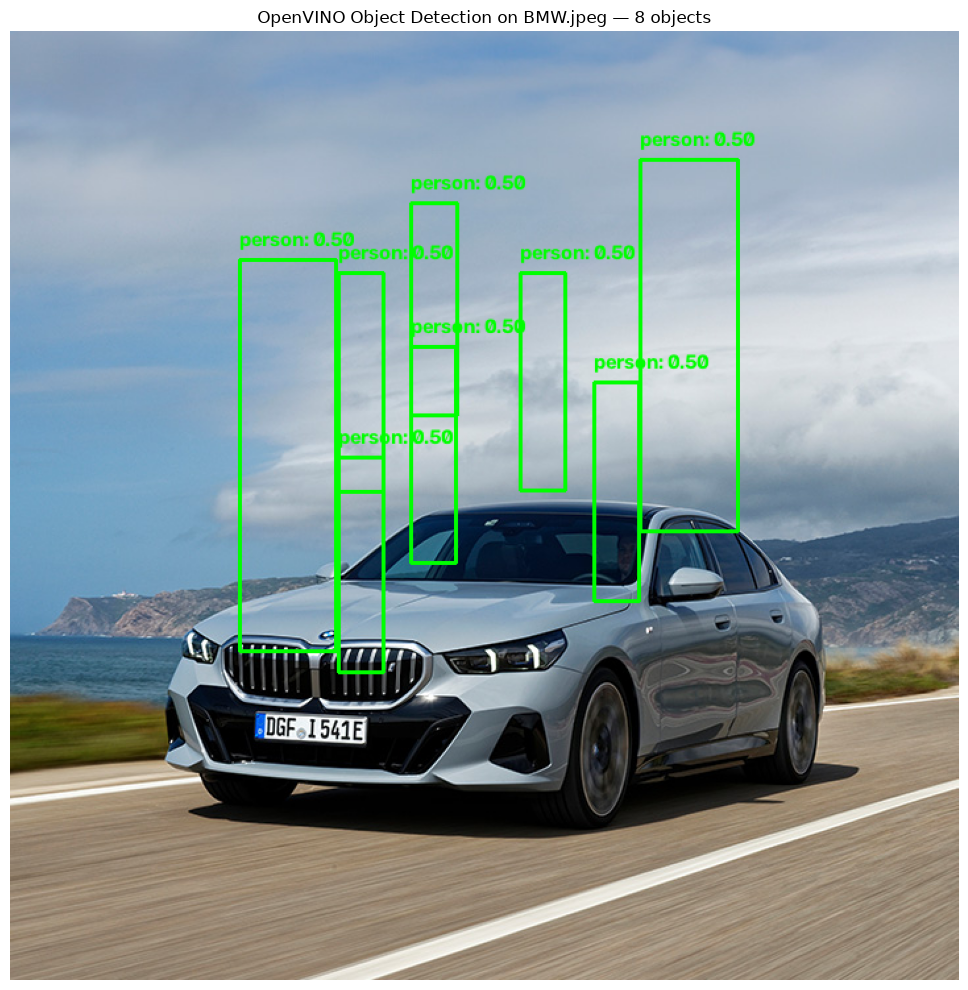

In [6]:
test_image_bgr = cv2.imread('BMW.jpeg')

start = time.time()
detections = detect_objects(test_image_bgr)
elapsed = time.time() - start

result_img = draw_detections(test_image_bgr.copy(), detections)
result_img_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)

print(f'Inference time: {elapsed:.3f} seconds')
print(f'Detections: {len(detections)}')
for det in detections:
    print(f"  {det['class_name']}: {det['score']:.2f} at {det['box']}")

plt.figure(figsize=(12, 10))
plt.imshow(result_img_rgb)
plt.title(f'OpenVINO Object Detection on BMW.jpeg — {len(detections)} objects')
plt.axis('off')
plt.show()

## 6. Webcam Object Detection

The following code captures frames from the default webcam, runs OpenVINO inference on each frame, and displays the results in a real-time window. Press **q** to exit the webcam window.

> **Note:** In a headless environment (e.g., a remote server without a display), the webcam demo cannot run. The code below is provided for local execution on a machine with a webcam.

In [7]:
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print('Error: Could not open webcam. Please ensure a webcam is connected.')
else:
    print('Webcam opened. Press q to quit.')
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        detections = detect_objects(frame)
        result = draw_detections(frame, detections)
        cv2.imshow('OpenVINO Object Detection', result)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()

## Summary

This notebook demonstrates the full OpenVINO object detection pipeline:

| Step | Description |
|------|-------------|
| **Model** | Pre-trained YOLOv3 (`person-vehicle-bike-detection-crossroad-yolov3-1020`) downloaded from the OpenVINO Model Zoo. |
| **Format** | OpenVINO IR (`.xml` + `.bin`) in FP16 precision. |
| **Backend** | OpenVINO Runtime (`openvino.Core`) with CPU target. |
| **Input** | 416×416 BGR image, normalized to [0, 1]. |
| **Output** | Bounding boxes with class labels and confidence scores for 80 COCO object categories. |

The pipeline is fully compatible with the OpenVINO AI Training Kit workflow: train or fine-tune a model → export to ONNX/PyTorch → convert to OpenVINO IR using `omz_converter` → deploy with `openvino.Core`.